# Lensless Imaging: DiffuserCam Reconstruction with ADMM

This notebook demonstrates how to reconstruct an image from a **lensless (DiffuserCam)** measurement using the **ADMM** (Alternating Direction Method of Multipliers) algorithm.

A DiffuserCam replaces the imaging lens with a piece of scotch tape (a diffuser).  Each point in the scene produces a unique caustic pattern on the sensor, encoding the scene information in a way that can be decoded computationally.

---

## Table of Contents
1. [Background: The Lensless Imaging Problem](#1-background)
2. [Data Loading and Visualisation](#2-data)
3. [The Forward Model](#3-forward-model)
4. [ADMM Reconstruction Algorithm](#4-admm)
5. [Results and Metrics](#5-results)
6. [Run from Scratch (optional)](#6-run-from-scratch)

In [1]:
import sys, os, pathlib

# Find the task root (the directory containing src/)
# Supports running from: tasks/lensless_imaging/ or tasks/lensless_imaging/notebooks/
_here = pathlib.Path(os.path.abspath('')).resolve()
_task_root = next(
    (p for p in [_here, _here.parent] if (p / 'src').is_dir()), _here
)
sys.path.insert(0, str(_task_root))

import numpy as np
import matplotlib.pyplot as plt
import json

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Convenience: resolve a path relative to the task root
def task_path(rel):
    return str(_task_root / rel)

---
## 1. Background: The Lensless Imaging Problem <a name="1-background"></a>

### Forward model

Under the **shift-invariant (LSI) approximation**, the lensless camera maps a scene $\mathbf{v} \in \mathbb{R}^{H \times W \times C}$ to a sensor measurement $\mathbf{b} \in \mathbb{R}^{H \times W \times C}$ via a **cropped 2-D convolution**:

$$
\mathbf{b} = \mathcal{C}\bigl(\mathbf{h} * \mathbf{v}\bigr)
$$

where:
- $\mathbf{h}$ is the measured **point-spread function (PSF)** — the caustic pattern produced by a single point source,
- $*$ denotes full 2-D linear (non-circular) convolution,
- $\mathcal{C}$ is the **crop** operator that extracts the central $(H \times W)$ region corresponding to the sensor footprint.

### Inverse problem

We want to recover $\mathbf{v}$ from $\mathbf{b}$ and $\mathbf{h}$.  This is ill-conditioned (the measurement is a blurred, noisy, compressed version of the scene), so regularisation is essential.

We solve the **TV-regularised non-negative least-squares** problem:

$$
\min_{\mathbf{v} \ge 0} \;\frac{1}{2}\|\mathbf{b} - A\mathbf{v}\|_2^2 + \tau \|\Psi\mathbf{v}\|_1
$$

where:
- $A\mathbf{v} = \mathcal{C}(\mathbf{h} * \mathbf{v})$ is the forward operator,
- $\Psi\mathbf{v}$ is the **image gradient** (finite differences) — the TV semi-norm promotes piece-wise constant / sharp-edge solutions,
- $\tau > 0$ balances data fidelity against regularisation,
- $\mathbf{v} \ge 0$ is the **non-negativity** constraint (pixel intensities must be non-negative).

---
## 2. Data Loading and Visualisation <a name="2-data"></a>

The data in `data/raw_data.npz` was obtained from the [LenslessPiCam](https://github.com/LCAV/LenslessPiCam) project (Bezzam et al., 2023).  It contains a **4× downsampled** measurement of a thumbs-up gesture captured with a scotch-tape DiffuserCam, together with the corresponding calibration PSF.

In [2]:
from src.preprocessing import load_npz

psf, measurement = load_npz(task_path('data/raw_data.npz'))

print(f'PSF:         shape={psf.shape}, dtype={psf.dtype}, '
      f'min={psf.min():.4f}, max={psf.max():.4f}')
print(f'Measurement: shape={measurement.shape}, dtype={measurement.dtype}, '
      f'min={measurement.min():.4f}, max={measurement.max():.4f}')

PSF:         shape=(760, 1014, 3), dtype=float32, min=0.0000, max=1.0000
Measurement: shape=(760, 1014, 3), dtype=float32, min=0.0000, max=1.0000


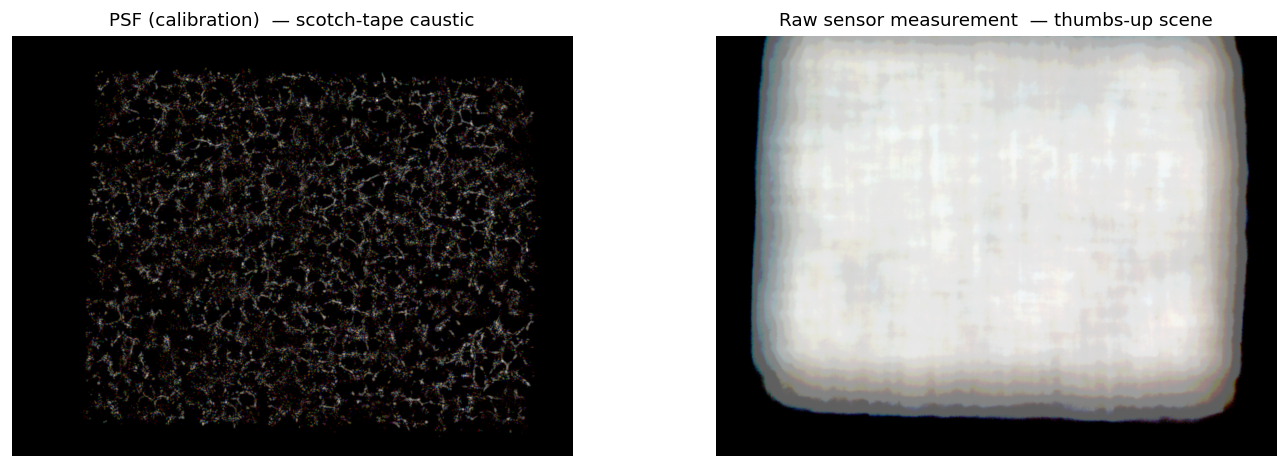

In [3]:
from src.visualization import normalise_for_display, gamma_correction

def show(ax, img, title, gamma=2.2):
    ax.imshow(gamma_correction(normalise_for_display(img), gamma))
    ax.set_title(title, fontsize=11)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show(axes[0], psf, 'PSF (calibration)  — scotch-tape caustic')
show(axes[1], measurement, 'Raw sensor measurement  — thumbs-up scene')
plt.tight_layout()
plt.show()

The **PSF** shows the characteristic speckle/caustic pattern produced by the diffuser for a single point source.  The **measurement** looks like a bright, structureless blob — there is no obvious thumbs-up shape visible before reconstruction.

---
## 3. The Forward Model <a name="3-forward-model"></a>

### FFT-based convolution

Linear convolution is computed efficiently using the FFT convolution theorem.
To avoid circular-convolution artefacts we **zero-pad** both the scene and the PSF to at least $2H-1 \times 2W-1$ (rounded up to a fast FFT size $p_H \times p_W$).

The PSF is **centre-padded** — placed at position $[s_H : s_H+H,\; s_W : s_W+W]$ in the padded array (with $s_H = \lfloor(p_H - H)/2\rfloor$).  After the inverse FFT we apply `ifftshift` to move the DC component from the array corner to the correct centre position.

The forward operator:
$$
M \mathbf{v}_{\text{pad}} = \texttt{ifftshift}\!\left(\mathcal{F}^{-1}\!\bigl(\tilde{H} \cdot \mathcal{F}(\mathbf{v}_{\text{pad}})\bigr)\right)
$$

where $\tilde{H} = \mathcal{F}(\text{pad}(\mathbf{h}))$ is the pre-computed FFT of the padded PSF.

The crop $\mathcal{C}$ extracts $[s_H : s_H+H,\; s_W : s_W+W]$ from the padded result.

The adjoint (matched filter / back-projection):
$$
M^H \mathbf{y} = \texttt{ifftshift}\!\left(\mathcal{F}^{-1}\!\bigl(\tilde{H}^* \cdot \mathcal{F}(\mathbf{y})\bigr)\right)
$$

In [4]:
from src.physics_model import RealFFTConvolve2D

conv = RealFFTConvolve2D(psf, norm='backward')
print(f'PSF shape:    {psf.shape}  → padded to {conv.padded_shape}')
print(f'Crop window:  rows [{conv._start[0]}:{conv._end[0]}], '
      f'cols [{conv._start[1]}:{conv._end[1]}]')
print(f'H dtype/shape: {conv.H.dtype}, {conv.H.shape}')

PSF shape:    (760, 1014, 3)  → padded to (1536, 2048)
Crop window:  rows [388:1148], cols [517:1531]
H dtype/shape: complex64, (1536, 1025, 3)


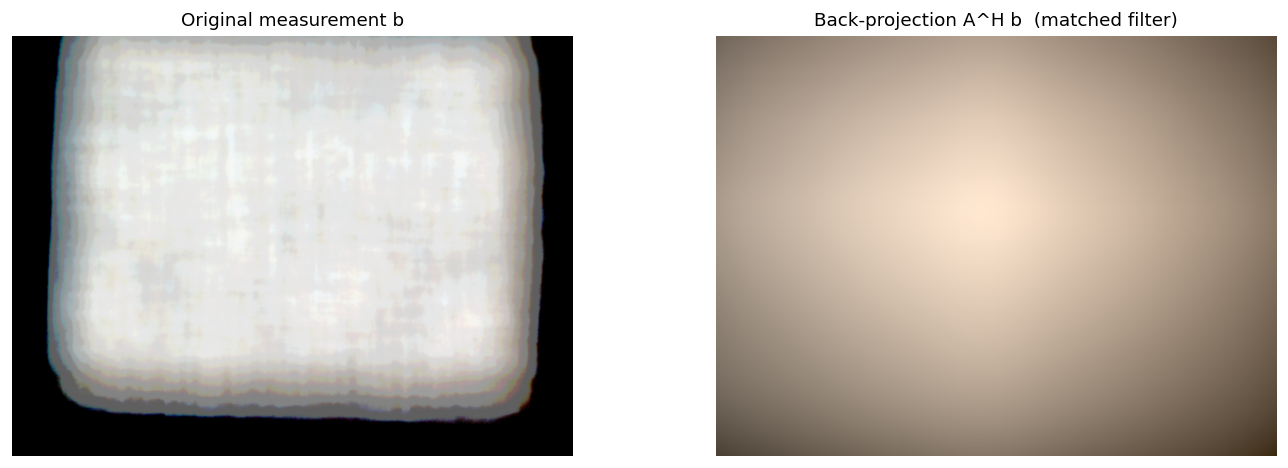

In [5]:
# Verify round-trip: forward(adjoint(measurement)) ≈ blurred version of measurement
# The reprojection of the measurement through A and A^H should preserve structure.
back_proj = conv._crop(conv.deconvolve(conv._pad(measurement)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show(axes[0], measurement, 'Original measurement b')
show(axes[1], back_proj, 'Back-projection A^H b  (matched filter)')
plt.tight_layout()
plt.show()

---
## 4. ADMM Reconstruction Algorithm <a name="4-admm"></a>

### Variable splitting

We solve the optimisation problem by introducing three **auxiliary variables** that decouple the convolution, the TV norm, and the non-negativity constraint:

$$
\min_{\mathbf{v}_{\text{pad}},\; \mathbf{u},\; \mathbf{x},\; \mathbf{w}}\;
  \frac{1}{2}\|\mathbf{b} - \mathcal{C}\mathbf{x}\|_2^2
  + \tau\|\mathbf{u}\|_1
  + \mathbb{1}_+(\mathbf{w})
\quad\text{s.t.}\quad
  \mathbf{x} = M\mathbf{v}_{\text{pad}},\;
  \mathbf{u} = \Psi\mathbf{v}_{\text{pad}},\;
  \mathbf{w} = \mathbf{v}_{\text{pad}}
$$

where all variables live in the **padded** space, $M$ is the padded circular convolution, $\mathcal{C}$ is the crop, $\Psi$ is the finite-difference gradient, and $\mathbb{1}_+$ is the indicator function of the non-negative orthant.

### ADMM update rules

The augmented Lagrangian (with dual variables $\boldsymbol{\xi}$, $\boldsymbol{\eta}$, $\boldsymbol{\rho}$ and penalty parameters $\mu_1, \mu_2, \mu_3$) is minimised by alternating closed-form sub-problems:

**Step 1 — TV proximal (soft threshold):**
$$
\mathbf{u}_{k+1} = \mathcal{S}_{\tau/\mu_2}\!\left(\Psi\mathbf{v}_{\text{pad},k} + \frac{\boldsymbol{\eta}_k}{\mu_2}\right)
\qquad \text{where }\mathcal{S}_\lambda(z)_i = \operatorname{sign}(z_i)\max(|z_i|-\lambda,0)
$$

**Step 2 — Data fidelity (element-wise division):**
$$
\mathbf{x}_{k+1} = X_{\text{div}} \odot \bigl(\boldsymbol{\xi}_k + \mu_1 M\mathbf{v}_{\text{pad},k} + \text{pad}(\mathbf{b})\bigr)
\qquad X_{\text{div}} = \frac{1}{\text{pad}(\mathbf{1}) + \mu_1}
$$

**Step 3 — Non-negativity projection:**
$$
\mathbf{w}_{k+1} = \max\!\left(\frac{\boldsymbol{\rho}_k}{\mu_3} + \mathbf{v}_{\text{pad},k},\; 0\right)
$$

**Step 4 — Image update (frequency-domain inversion):**
$$
\mathbf{r}_k = \mu_3\mathbf{w}_{k+1} - \boldsymbol{\rho}_k
  + \Psi^\top(\mu_2\mathbf{u}_{k+1} - \boldsymbol{\eta}_k)
  + M^H(\mu_1\mathbf{x}_{k+1} - \boldsymbol{\xi}_k)
$$
$$
\mathbf{v}_{\text{pad},k+1} = \mathcal{F}^{-1}\!\bigl(R_{\text{div}} \odot \mathcal{F}(\mathbf{r}_k)\bigr)
\qquad R_{\text{div}} = \frac{1}{\mu_1|\tilde{H}|^2 + \mu_2|\tilde{\Psi}|^2 + \mu_3}
$$

Here $|\tilde{H}|^2$ is the power spectrum of the PSF, $|\tilde{\Psi}|^2 = \mathcal{F}(\Delta)$ with $\Delta$ the discrete Laplacian kernel (the eigenvalues of $\Psi^\top\Psi$).

**Dual (multiplier) updates:**
$$
\boldsymbol{\xi}_{k+1} = \boldsymbol{\xi}_k + \mu_1(M\mathbf{v}_{k+1} - \mathbf{x}_{k+1})
$$
$$
\boldsymbol{\eta}_{k+1} = \boldsymbol{\eta}_k + \mu_2(\Psi\mathbf{v}_{k+1} - \mathbf{u}_{k+1})
$$
$$
\boldsymbol{\rho}_{k+1} = \boldsymbol{\rho}_k + \mu_3(\mathbf{v}_{k+1} - \mathbf{w}_{k+1})
$$

All four pre-computed quantities ($\tilde{H}$, $R_{\text{div}}$, $X_{\text{div}}$, $\text{pad}(\mathbf{b})$) are computed once before the loop.

> **Finite-difference adjoint.**  With $\Psi\mathbf{v} = \text{roll}(\mathbf{v}, 1) - \mathbf{v}$ (one-pixel forward shift), the adjoint satisfies $\langle\Psi\mathbf{v}, \mathbf{u}\rangle = \langle\mathbf{v}, \Psi^\top\mathbf{u}\rangle$ with:
> $$\Psi^\top\mathbf{u} = \text{roll}(\mathbf{u}, -1) - \mathbf{u} = \mathbf{u}_{i+1} - \mathbf{u}_i$$
> Note the sign: $\Psi^\top$ uses a **negative** shift ($-1$), not a positive one.

In [6]:
from src.solvers import ADMM, finite_diff, finite_diff_adj, finite_diff_gram

# Verify adjoint: <Ψv, u> == <v, ΨᵀΨu>
np.random.seed(0)
H, W, C = psf.shape
v_test = np.random.randn(H, W, C).astype(np.float32)
u_test = np.random.randn(2, H, W, C).astype(np.float32)

lhs = np.sum(finite_diff(v_test) * u_test)
rhs = np.sum(v_test * finite_diff_adj(u_test))
print(f'Adjoint test: <Ψv, u> = {lhs:.6f},  <v, Ψᵀu> = {rhs:.6f}')
print(f'Relative error: {abs(lhs-rhs)/abs(lhs):.2e}')  # should be ~1e-7

Adjoint test: <Ψv, u> = -466.703918,  <v, Ψᵀu> = -466.704987
Relative error: 2.29e-06


---
## 5. Results and Metrics <a name="5-results"></a>

We load the **pre-computed reconstruction** (300 ADMM iterations, ~5 minutes on CPU) from `evaluation/reference_outputs/`.  To run from scratch see [Section 6](#6-run-from-scratch).

In [7]:
# Load pre-computed reconstruction
reconstruction = np.load(task_path('evaluation/reference_outputs/reconstruction.npy'))
with open(task_path('evaluation/reference_outputs/metrics.json')) as f:
    metrics = json.load(f)

print(f'Reconstruction shape: {reconstruction.shape}')
print(f'Value range:          [{reconstruction.min():.6f}, {reconstruction.max():.6f}]')
print(f'\nConfiguration:')
for k, v in metrics.items():
    print(f'  {k}: {v}')

Reconstruction shape: (760, 1014, 3)
Value range:          [0.000000, 0.007339]

Configuration:
  n_iter: 300
  mu1: 1e-06
  mu2: 1e-05
  mu3: 4e-05
  tau: 0.0001
  reprojection_nrmse: 1.0969911813735962


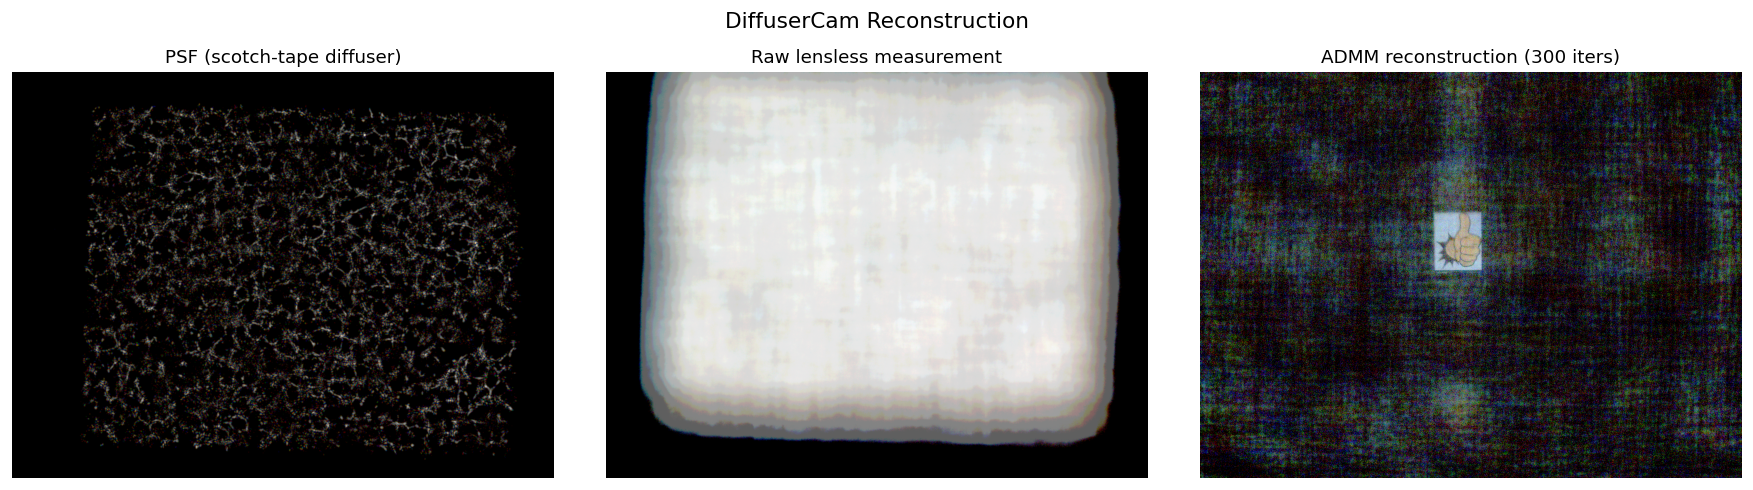

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
show(axes[0], psf, 'PSF (scotch-tape diffuser)')
show(axes[1], measurement, 'Raw lensless measurement')
show(axes[2], reconstruction, 'ADMM reconstruction (300 iters)')
plt.suptitle('DiffuserCam Reconstruction', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

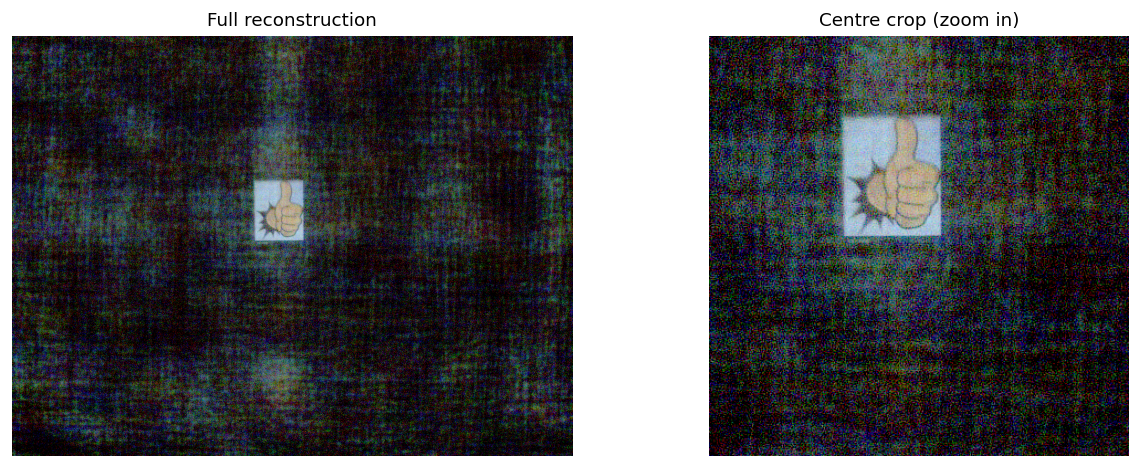

In [9]:
# Zoom in on the reconstruction to see the thumbs-up clearly
H, W, C = reconstruction.shape

# The scene is approximately in the centre quarter
row_c, col_c = H // 2, W // 2
half = min(H, W) // 4
crop = reconstruction[
    row_c - half : row_c + half,
    col_c - half : col_c + half,
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
show(axes[0], reconstruction, 'Full reconstruction')
show(axes[1], crop, 'Centre crop (zoom in)')
plt.tight_layout()
plt.show()

### Reprojection metric

Since no ground-truth image is available, we evaluate reconstruction quality via the **reprojection NRMSE**: re-apply the forward model $A$ to the reconstruction $\hat{\mathbf{v}}$ and compare to the original measurement $\mathbf{b}$:

$$
\text{NRMSE}_{\text{reproj}} = \frac{\|A\hat{\mathbf{v}} - \mathbf{b}\|_2}{\|\mathbf{b}\|_2}
$$

A value near 1.0 indicates that the reconstruction is plausible given the scale of the measurement.  (The PSF is peak-normalised, so $\|A\mathbf{v}\|$ is much smaller than $\|\mathbf{b}\|$ for a natural-scale reconstruction — values > 1 are expected.)

In [10]:
from src.physics_model import RealFFTConvolve2D

conv = RealFFTConvolve2D(psf)
reprojected = conv.forward(reconstruction)
nrmse = float(np.linalg.norm(reprojected - measurement) / np.linalg.norm(measurement))
print(f'Reprojection NRMSE: {nrmse:.4f}')

Reprojection NRMSE: 1.0970


---
## 6. Run from Scratch (optional) <a name="6-run-from-scratch"></a>

The following cell runs the full ADMM pipeline from scratch (~5 minutes on CPU).  Uncomment and execute to reproduce the reference outputs.

In [11]:
# from src.preprocessing import load_npz
# from src.solvers import ADMM
# from src.visualization import plot_overview
# 
# psf, measurement = load_npz(task_path('data/raw_data.npz'))
# 
# solver = ADMM(
#     psf,
#     mu1=1e-6,   # penalty for x = Mv
#     mu2=1e-5,   # penalty for u = Ψv
#     mu3=4e-5,   # penalty for w = v  (non-negativity)
#     tau=1e-4,   # TV regularisation weight
# )
# solver.set_data(measurement)
# reconstruction = solver.apply(n_iter=300, verbose=True)
# 
# fig = plot_overview(psf, measurement, reconstruction, gamma=2.2)
# plt.show()

---
## Summary

| Step | Operation | Description |
|------|-----------|-------------|
| 1 | Load data | PSF + measurement, 4× downsampled, float32 [0, 1] |
| 2 | Forward model | Padded FFT convolution + crop; adjoint uses conjugate filter |
| 3 | ADMM | 300 iterations, TV + non-negativity, ~5 min CPU |
| 4 | Result | Thumbs-up visible in centre of reconstruction |

**Key design choices:**
- **Centre-padding**: PSF placed at `[start:end]` in padded array; `ifftshift` applied after `irfft2` to correct the phase offset.
- **R_divmat in float64**: $R_{\text{div,max}} \approx 1/\mu_3 \approx 25000$; computing in float32 introduces rounding errors that grow by ~25000× per iteration and diverge.
- **Correct adjoint sign**: $\Psi^\top\mathbf{u} = \text{roll}(\mathbf{u},-1) - \mathbf{u}$, NOT $\mathbf{u} - \text{roll}(\mathbf{u},-1)$ — the wrong sign turns TV regularisation into TV amplification.

**References:**
- Antipa et al. (2018). DiffuserCam. *Optica*.
- Bezzam et al. (2023). LenslessPiCam. *JOSS*, 8(86).
- Boyd et al. (2011). ADMM. *Found. Trends Mach. Learn.*, 3(1).